# Gadget Sentiment Analyzer: Fine-Tuning IndoBERT
**Analisis Sentimen Opini Publik pada Ulasan Gadget Berbahasa Indonesia**

---

## Ringkasan Proyek
Proyek ini berfokus pada pengembangan model *Natural Language Processing* (NLP) untuk membaca dan mengklasifikasikan sentimen opini publik secara otomatis menjadi tiga kategori: **Netral, Positif, dan Negatif**.

Model ini dilatih (*Fine-Tuning*) menggunakan arsitektur **IndoBERT** dengan memanfaatkan dataset ulasan perangkat teknologi (*gadget*) yang diekstrak langsung dari kolom komentar *channel* YouTube **Gadgetin**. Proyek ini dirancang untuk mendeteksi gaya bahasa sehari-hari *netizen* Indonesia, termasuk penggunaan bahasa gaul (*slang*), singkatan, hingga majas sarkasme.

## Apa yang Kami Lakukan di Proyek Ini?
Untuk mencapai metrik evaluasi yang tinggi (F1-Score: 0.82, Akurasi: 82%), alur kerja (*pipeline*) yang saya rancang dalam proyek ini meliputi:

1. **Data Crawling (YouTube API v3):** Mengekstrak data komentar mentah secara dinamis dari berbagai video *review gadget* populer.
2. **Data Augmentation:** Menangani ketimpangan jumlah data (*class imbalance*) dengan menyuntikkan data buatan (*Generative AI*) khusus untuk kelas sentimen minoritas.
3. **Text Preprocessing:** Membangun algoritma pembersihan teks (penghapusan tautan, emoji, duplikasi karakter) dan menerjemahkan bahasa gaul/alay ke dalam bahasa baku menggunakan kamus modifikasi (*custom dictionary*).
4. **Model Fine-Tuning:** Melatih model pra-latih `indobenchmark/indobert-base-p2` menggunakan *PyTorch* dan ekosistem *Hugging Face* dengan penyesuaian *hyperparameter* untuk mencegah *overfitting*.
5. **Model Deployment:** Mengunggah model akhir ke Hugging Face Hub dan mengintegrasikannya ke dalam antarmuka aplikasi web interaktif berbasis **Streamlit**.

---

## Tautan Penting
* **Lihat Langsung di Colab:** [Link Colab](https://colab.research.google.com/drive/1YeZGyB5vH-ATHY19MzqlAvcAFUph-xCV?usp=sharing)
* **Coba Aplikasinya Langsung:** [Aplikasi Streamlit Gadget Sentiment Analyzer](https://indobert-sentiment-analysis-gadget.streamlit.app/)
* **Lihat Kode Sumber (GitHub):** [Repository Proyek Sentimen](https://github.com/Seixin/IndoBert-Sentiment-Analysis.git)
* **Akses Model (Hugging Face):** [Repositori Model Sentimen](https://huggingface.co/MichaelJo23/indobert-sentimen-gadgetin)

---


## 1. Persiapan Lingkungan Kerja (*Environment Setup*)
Proses instalasi dan pembaruan (*upgrade*) pustaka utama yang dibutuhkan untuk pemrosesan data, evaluasi metrik, dan *fine-tuning* model *Deep Learning* (IndoBERT).


In [ ]:
!pip install --upgrade transformers datasets evaluate accelerate torch torchvision scikit-learn pandas openpyxl

## 2. Inisialisasi Modul dan Pustaka
Mengimpor seluruh pustaka Python yang diperlukan untuk siklus *Machine Learning*. Tahapan ini mencakup modul untuk pembersihan teks (*RegEx*), manipulasi *dataframe*, visualisasi distribusi kelas, hingga pemanggilan arsitektur pra-latih IndoBERT dari ekosistem Hugging Face.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
from google.colab import drive
from google.colab import files
from google.colab import userdata
import evaluate
from googleapiclient.discovery import build

## 3. Ekstraksi Data Primer (YouTube Data API v3)
Tahapan ini berfokus pada pengumpulan dataset organik dengan melakukan ekstraksi komentar dari beberapa tautan video YouTube referensi. Proses iterasi (*crawling*) dilakukan secara dinamis dan dibatasi hingga 200 komentar per video menggunakan mekanisme *pagination* (`nextPageToken`). Data mentah (*raw data*) yang diperoleh kemudian diagregasi ke dalam *DataFrame* dan diekspor sebagai file CSV untuk tahap prapemrosesan lanjutan.

In [ ]:
API_KEY = userdata.get('SECRET')

video_ids = [
    'oM9v6P41tRA',
    'G1TRm2B-h1M',
    '9-poYwCZxDQ',
    'NVXzM58nNes',
    'hUviCuxx3xE'
]
youtube = build('youtube', 'v3', developerKey=API_KEY)
semua_komentar=[]

for video_id in video_ids:
  print(f'Sedang menarik data dari video_id:{video_id}...')

  request = youtube.commentThreads().list(
      part='snippet',
      videoId = video_id,
      maxResults= 100,
      textFormat = 'plainText'
  )

  jumlah_diambil=0
  batas_maksimal=200

  while request is not None and jumlah_diambil < batas_maksimal:
    response = request.execute()
    for item in response['items']:
      komentar=item['snippet']['topLevelComment']['snippet']['textDisplay']
      author=item['snippet']['topLevelComment']['snippet']['authorDisplayName']

      semua_komentar.append({
          'Video_ID':video_id,
          'Author':author,
          'Komentar':komentar
      })

      jumlah_diambil+=1
      if jumlah_diambil >= batas_maksimal:
        break

    if 'nextPageToken' in response and jumlah_diambil < batas_maksimal:
      request = youtube.commentThreads().list_next(
          previous_request=request,
          previous_response=response
      )
    else:
      break

df= pd.DataFrame(semua_komentar)
nama_file="Dataset_Komentar_Gadgetin.csv"
df.to_csv(nama_file, index=False, encoding='utf-8')

print(f"\nSelesai! Total komentar ditarik: {len(df)}")
print("Mendownload file otomatis...")

files.download(nama_file)

## 4. Pemuatan Dataset Akhir dan Penambahan Data AI (*Data Augmentation*)
Tahapan ini berfokus pada pemuatan *dataset* gabungan yang sudah siap diolah ke dalam sistem. Untuk mengatasi masalah jumlah data yang tidak seimbang (*class imbalance*) pada data asli, diterapkan teknik *Data Augmentation* dengan menambahkan sekitar 800 komentar buatan yang diproduksi secara khusus menggunakan *Generative AI*. Selain itu, seluruh ulasan asli hasil tarikan YouTube (*scraping*) sebelumnya sudah diberi label sentimen (0: Netral, 1: Positif, 2: Negatif) dan dibersihkan dari baris yang kosong (*missing values*) untuk memastikan kualitas data sebelum model mulai dilatih.


In [14]:
drive.mount('/content/drive')

path = '/content/drive/MyDrive/SentimenAnalisis/dataset_augmented_v5_1800.xlsx'

df = pd.read_excel(path)
df = df.dropna(subset=['sentiment'])
df['sentiment'] = df['sentiment'].astype(int)

print(f"Total data: {len(df)}")
print("\nDistribusi sentimen:")
print(df['sentiment'].value_counts().sort_index().rename({0:'Netral', 1:'Positif', 2:'Negatif'}))
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total data: 1800

Distribusi sentimen:
sentiment
Netral     600
Positif    600
Negatif    600
Name: count, dtype: int64


,Video_ID,Author,Komentar,sentiment
0,oM9v6P41tRA,@user-yb2mh5ps9t,"kalo dengan budget yg sama, mending beli seri ...",0
1,oM9v6P41tRA,@hadidfaithmuhammad7004,"Btw bang, aku user POCO M7 PRO 5G dan udah ada...",0
2,oM9v6P41tRA,@Toritori-b4s,Bang david gimana setelah nyoba pakai x8 proma...,0
3,oM9v6P41tRA,@SammyEriksoon_Game,S itu SUNAT ya hahahahaha,0
4,oM9v6P41tRA,@ceritaShakeel,dibuat apa dirakit?? wkwkwkwk,0


## 5. Preprocessing Teks
Tahap ini sangat penting untuk merapikan komentar *netizen* yang berantakan sebelum diajarkan ke dalam model AI. Proses pembersihan yang dilakukan pada tahap ini meliputi:
* **Mengubah huruf kecil semua** agar model tidak bingung membedakan "Bagus" dan "bagus".
* **Menghapus elemen tidak penting** seperti tautan (*link*), emoji, sebutan (*mention* @), dan tagar (*hashtag* #).
* **Menerjemahkan bahasa gaul/alay** menjadi bahasa Indonesia yang baku menggunakan kamus buatan sendiri (contoh: "bgt" menjadi "banget", "anjir" menjadi "astaga").
* **Merapikan ketikan yang berlebihan** (contoh: "bagussss" menjadi "baguss", atau tanda seru "!!!" menjadi "!").
* **Menyaring komentar kosong**, yaitu membuang komentar yang panjangnya kurang dari 2 kata, karena biasanya tidak memiliki makna sentimen yang jelas.


In [15]:
kamus_alay = {
    "bgt": "banget", "bangets": "banget", "bngt": "banget",
    "bgtt": "banget", "bgtttt": "banget",
    "bgttt": "banget",
    "gak": "tidak", "ga": "tidak", "gk": "tidak", "nggak": "tidak", "ngga": "tidak",
    "gue": "saya", "gw": "saya", "aku": "saya",
    "lo": "kamu", "lu": "kamu", "elu": "kamu",
    "udh": "sudah", "udah": "sudah",
    "emg": "memang", "emang": "memang",
    "kayak": "seperti", "kyk": "seperti",
    "krn": "karena", "karna": "karena",
    "yg": "yang",
    "dgn": "dengan",
    "utk": "untuk", "buat": "untuk",
    "hrs": "harus",
    "blm": "belum",
    "jg": "juga",
    "lg": "lagi",
    "msh": "masih",
    "sdh": "sudah",
    "bs": "bisa",
    "sm": "sama",
    "dr": "dari",
    "tp": "tapi",
    "skrg": "sekarang",
    "kmrn": "kemarin",
    "nntn": "nonton",
    "beli": "beli",
    "hps": "hapus",
    "hp": "handphone",
    "dpt": "dapat",
    "mantul": "mantap betul", "mantap": "mantap",
    "gocap": "lima puluh ribu",
    "goib": "habis",
    "gocil": "tidak ada",
    "najis": "sangat jelek",
    "ampas": "buruk",
    "cuan": "untung",
    "gabut": "tidak ada kerjaan",
    "wkwk": "", "wkwkwk": "", "wkwkwkwk": "",
    "haha": "", "hahaha": "", "hihi": "",
    "anjir": "astaga", "anjay": "astaga", "anying": "astaga",
    "gila": "luar biasa", "gilak": "luar biasa",
    "sih": "", "deh": "", "dong": "", "nih": "",
}

def bersihkan_teks(teks):
    teks = str(teks).lower().strip()

    teks = re.sub(r'http\S+|www\S+', '', teks)
    teks = re.sub(r'@\w+|#\w+', '', teks)
    teks = teks.encode('ascii', 'ignore').decode('ascii')
    for alay, baku in kamus_alay.items():
        teks = re.sub(r'\b' + re.escape(alay) + r'\b', baku, teks)

    teks = re.sub(r'(.)\1{2,}', r'\1\1', teks)

    teks = re.sub(r'([!?.]){2,}', r'\1', teks)

    teks = re.sub(r'\b\d+\b', '', teks)

    teks = re.sub(r'\s+', ' ', teks).strip()

    return teks

df['clean_comment'] = df['Komentar'].apply(bersihkan_teks)

df = df[df['clean_comment'].str.split().str.len() >= 2].reset_index(drop=True)

print(f"Data setelah filtering komentar terlalu pendek: {len(df)}")
df[['Komentar','clean_comment','sentiment']].sample(5)

Data setelah filtering komentar terlalu pendek: 1781


,Komentar,clean_comment,sentiment
824,solusinya pakai hp samsung yg entry level tapi...,solusinya pakai handphone samsung yang entry l...,1
1470,"first impression: premium banget rasanya, pada...","first impression: premium banget rasanya, pada...",1
233,bang buat test game tolong tambahin test game ...,bang untuk test game tolong tambahin test game...,0
798,Kok hp cina gk pernah rusak seperti hp samsung...,kok handphone cina tidak pernah rusak seperti ...,2
777,Tips pencegahan lightsaber untuk hp samsung da...,tips pencegahan lightsaber untuk handphone sam...,0


## 6. Pemisahan Data Latih dan Data Uji
Langkah ini memisahkan *dataset* ke dalam kelompok *Training Set* (80%) untuk proses pembelajaran AI, dan *Test Set* (20%) sebagai alat evaluasi akhir. Penggunaan parameter pembagian proporsional (*stratify*) diterapkan di sini untuk mencegah penumpukan satu jenis sentimen pada kelompok tertentu. Hal ini menjamin bahwa model akan diuji dengan komposisi tingkat kesulitan data yang setara dengan saat ia dilatih.

In [16]:
df_model = df[['clean_comment', 'sentiment']].copy()

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['sentiment']
)

print("Distribusi Dataset Train (80%):")
print(train_df['sentiment'].value_counts().sort_index().to_dict())

print("\nDistribusi Dataset Test (20%):")
print(test_df['sentiment'].value_counts().sort_index().to_dict())

Distribusi Dataset Train (80%):
{0: 473, 1: 474, 2: 477}

Distribusi Dataset Test (20%):
{0: 118, 1: 119, 2: 120}


## 7. Proses Tokenisasi dan Transformasi Dataset
Tahapan ini berfungsi untuk mengonversi *dataframe* biasa menjadi format *Dataset* khusus yang kompatibel dengan ekosistem Hugging Face. Data teks kemudian diproses melalui fungsi tokenisasi dari `indobenchmark/indobert-base-p2`. Untuk menjaga efisiensi memori selama proses pelatihan model, panjang maksimal setiap kalimat dibatasi hingga 128 token. Kolom target juga diubah namanya menjadi `labels` dan seluruh data dikonversi ke dalam format PyTorch (`torch`) untuk persiapan alur pelatihan (Training).

In [ ]:
model_checkpoint = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

dataset = DatasetDict({'train': train_dataset, 'test': test_dataset})

def tokenize_function(examples):
    return tokenizer(
        examples['clean_comment'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['clean_comment'])
tokenized_datasets = tokenized_datasets.rename_column('sentiment', 'labels')
tokenized_datasets.set_format('torch')

print(tokenized_datasets)

## 8. Fine Tuning Model
Pada fase komputasi utama ini, arsitektur *pre-trained* IndoBERT dilatih ulang menggunakan parameter yang telah dioptimalkan secara ketat. Proses pelatihan dikonfigurasi menggunakan `TrainingArguments` dengan *learning rate* 2e-5, *batch size* 16, dan *warmup ratio* 0.1 untuk menjaga stabilitas *gradient descent*. Evaluasi metrik berfokus pada capaian rata-rata harmoni (*F1-Score Macro*) guna mengatasi sisa bias kelas. Algoritma juga dilengkapi dengan fungsi `EarlyStoppingCallback` untuk menghentikan iterasi komputasi secara prematur apabila terjadi indikasi *overfitting*, memastikan model akhir yang tersimpan adalah iterasi dengan performa paling stabil.

In [ ]:
id2label = {0: "Netral", 1: "Positif", 2: "Negatif"}
label2id = {"Netral": 0, "Positif": 1, "Negatif": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": accuracy, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Memulai proses Fine-Tuning IndoBERT...")
trainer.train()

## 9. Evaluasi Model dengan Laporan Klasifikasi
Pada tahap akhir ini, model yang telah selesai dilatih dievaluasi secara komprehensif menggunakan himpunan data uji (*test dataset*). Tebakan probabilitas dari model diubah menjadi label akhir, lalu dikomparasi secara langsung dengan label aktual. Hasil evaluasinya kemudian dirangkum menggunakan fungsi `classification_report` untuk menampilkan performa model pada masing-masing kelas (Netral, Positif, Negatif) berdasarkan standar metrik industri.

In [18]:
output_prediksi = trainer.predict(tokenized_datasets["test"])

tebakan_indobert = np.argmax(output_prediksi.predictions, axis=-1)
label_asli = output_prediksi.label_ids

print("=" * 55)
print("         HASIL EVALUASI INDOBERT")
print("=" * 55)
print(classification_report(
    label_asli,
    tebakan_indobert,
    target_names=["Netral (0)", "Positif (1)", "Negatif (2)"]
))

         HASIL EVALUASI INDOBERT
              precision    recall  f1-score   support

  Netral (0)       0.83      0.76      0.80       118
 Positif (1)       0.87      0.82      0.84       119
 Negatif (2)       0.78      0.88      0.83       120

    accuracy                           0.82       357
   macro avg       0.83      0.82      0.82       357
weighted avg       0.83      0.82      0.82       357



## 10. Evaluasi Model dengan Heatmap
Langkah ini bertujuan untuk memvisualisasikan hasil evaluasi model agar lebih mudah dibaca. *Confusion Matrix* membandingkan langsung label aktual dengan tebakan hasil prediksi model. Kode ini menghasilkan dua buah grafik: grafik pertama menampilkan jumlah distribusi data riil secara absolut, dan grafik kedua menampilkan persentase akurasi di tiap kelas sentimen. Kotak yang berada di luar garis diagonal utama menunjukkan letak kesalahan klasifikasi (*misclassification*) yang masih dilakukan oleh model.

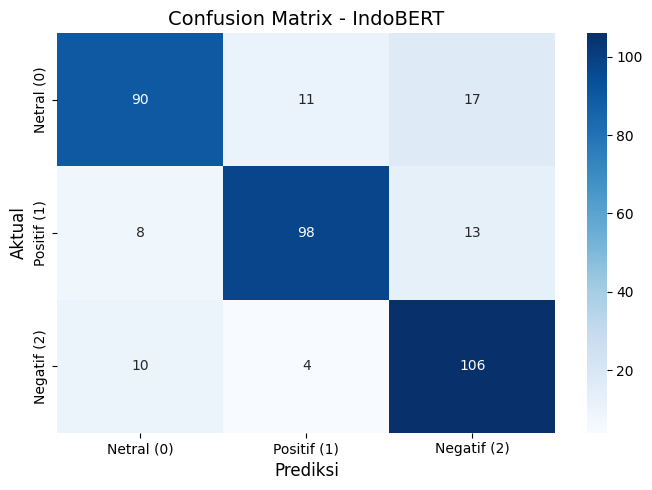

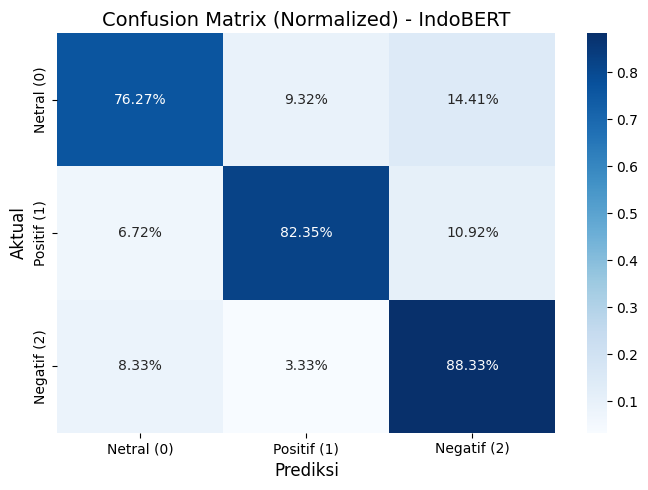

In [19]:
cm_bert = confusion_matrix(label_asli, tebakan_indobert)
label_names = ['Netral (0)', 'Positif (1)', 'Negatif (2)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - IndoBERT', fontsize=14)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

cm_persen = cm_bert.astype('float') / cm_bert.sum(axis=1, keepdims=True)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_persen, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix (Normalized) - IndoBERT', fontsize=14)
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Simulasi Prediksi Langsung (*Live Inference*) pada Kasus Uji Ekstrem
Langkah ini mendemonstrasikan ketahanan (*robustness*) model terhadap data-data anomali yang sering muncul pada ulasan produk. Model dipanggil menggunakan API `pipeline` dari Hugging Face, kemudian diuji menggunakan sekumpulan kalimat *hard examples* yang memuat gaya bahasa sarkastis, ambiguitas perbandingan, dan *slang* internet. Setiap kalimat yang masuk akan melalui tahap *preprocessing* otomatis terlebih dahulu sebelum diprediksi. Tujuannya adalah memvalidasi apakah model mampu mengenali konteks keluhan yang dibalut dengan pujian palsu atau hiperbola.

In [20]:
nlp_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0
)

def tebak_sentimen_bert(kalimat):
    clean = bersihkan_teks(kalimat)
    hasil = nlp_pipeline(clean)[0]
    print(f"Input   : '{kalimat}'")
    print(f"Clean   : '{clean}'")
    print(f"Prediksi: {hasil['label']}  (keyakinan: {hasil['score']*100:.1f}%)")
    print("-" * 55)

komentar_uji = [
    "Desainnya sih rasa flagship, tapi dipakai scroll TikTok 10 menit udah bisa buat nyetrika baju.",
    "Layar emang super jernih, cuma sayang sinyalnya kembang kempis ampun dah.",
    "Bang, request komparasi seri ini dong, mending mana sama hape tetangga?",
    "Gila ini hape, main Genshin rata kanan tetep adem ayem lancar jaya.",
    "Resolusi kamera katanya dewa, pas di-zoom muka gue malah kayak buronan polsek.",
    "Asli worth it parah sih dengan harga segini.",
    "Hape ganjalan pintu mending ditarik aja dari pasaran.",
    "Makasih banget update software-nya, hape gue layarnya jadi dapet fitur garis hijau gratis.",
    "Katanya spek gaming rata kanan, tapi buka menu aja ngelag sungkem suhu.",
    "Haptic feedback-nya dapet banget, getarannya kerasa kayak hape mahal.",
    "Batre badak bener, sampe lupa kapan terakhir nyolok charger.",
    "mantep poll",
    "ampas banget",
]

for k in komentar_uji:
    tebak_sentimen_bert(k)

Input   : 'Desainnya sih rasa flagship, tapi dipakai scroll TikTok 10 menit udah bisa buat nyetrika baju.'
Clean   : 'desainnya rasa flagship, tapi dipakai scroll tiktok menit sudah bisa untuk nyetrika baju.'
Prediksi: Negatif  (keyakinan: 99.1%)
-------------------------------------------------------
Input   : 'Layar emang super jernih, cuma sayang sinyalnya kembang kempis ampun dah.'
Clean   : 'layar memang super jernih, cuma sayang sinyalnya kembang kempis ampun dah.'
Prediksi: Negatif  (keyakinan: 99.1%)
-------------------------------------------------------
Input   : 'Bang, request komparasi seri ini dong, mending mana sama hape tetangga?'
Clean   : 'bang, request komparasi seri ini , mending mana sama hape tetangga?'
Prediksi: Netral  (keyakinan: 99.8%)
-------------------------------------------------------
Input   : 'Gila ini hape, main Genshin rata kanan tetep adem ayem lancar jaya.'
Clean   : 'luar biasa ini hape, main genshin rata kanan tetep adem ayem lancar jaya.'
Prediks

## 12. Ekspor Model untuk Tahap Implementasi (*Deployment*)
Fase ini merupakan langkah terakhir dalam alur *Machine Learning* di lingkungan penelitian (Colab). Model IndoBERT yang telah melalui proses *Fine-Tuning* beserta konfigurasi *tokenizer*-nya diekspor ke penyimpanan permanen (Google Drive). File arsitektur model dan kamus *vocab* ini nantinya akan dipanggil kembali sebagai *backend* utama pada antarmuka aplikasi berbasis web (Streamlit) agar dapat digunakan secara *real-time* oleh pengguna akhir.

In [ ]:
save_path = "/content/drive/MyDrive/SentimenAnalisis/model_indobert_final"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model tersimpan di: {save_path}")